### WS 2020/21 <span style="float: right;">GET Lab<br />Paderborn University</span><br />
## <center>Digital Image Processing I<br /><br />Task Sheet 8</center>
---

### Overview

The objective of this exercise is to study spatial sharpening filters. The filter masks used for this purpose are based on first and second order derivatives which are usually approximated by filter masks. The following figure shows a subset of the most common masks for this:

<br />
<center><img src="images/masks.png"  width="800px" /></center>

---

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
import time

dpi = plt.rcParams['figure.dpi']

# plot grayscale image in original size
def plot_img_orig(img):
    rows, cols = img.shape # image size
    fig = plt.figure(figsize = (cols/dpi, rows/dpi))
    fig.add_axes([0, 0, 1, 1])
    plt.axis('off')
    plt.imshow(img, cmap='gray', vmin=0, vmax=255)
    plt.show()

#### <span style="color: RoyalBlue; font-weight: bold;">Task 8.1</span> Normalization and Clipping

Depending on the specific image processing method used (e.g., differentiating an image or adding it to another), the resulting gray values can exceed the common range of $[0, 255]$. While the exceeding values can be kept for further processing steps, the images cannot be displayed directly. In this case, there are two standard methods to adjust the values: normalization and clipping.

Normalization is a variant of range scaling and therefore a gray-level transformation, where the goal is the following mapping: $[a, b] \rightarrow [0, 255]$, where $[a, b]$ is the range of input gray values (see task sheet 3). The OpenCV function <a href="https://docs.opencv.org/4.2.0/d2/de8/group__core__array.html#ga87eef7ee3970f86906d69a92cbf064bd">`normalize` ↗</a> can be used to normalize an image in this way.

Clipping means that gray values smaller then $0$ are set to $0$, and that gray values larger then $255$ are set to $255$ (gray values exceeding the common range are clipped):

$$
f(x,y) =
\begin{cases}
0 &\ \mathrm{if}\ f(x,y) < 0\\
255 &\ \mathrm{if}\ f(x,y) > 255\\
f(x,y)   &\ \text{otherwise}
\end{cases}
$$

Implement / solve the following tasks:
1. Write a function for clipping a given image.
2. The image *h-pattern2.png* has three fields with the gray values $0$, $128$, and $255$, respectively. Read this image as a grayscale image and plot it.
3. To create an image with gray values which exceed the common range of $[0, 255]$, substract $128$ from each gray value and plot the result.
4. Normalize this image on the one hand, clip this image on the other hand, and plot and compare the results.

In [4]:
# write your code here

# clip given image
def clip(img):
    rows, cols = img.shape # image size
    print(np.min(rows), np.min(cols), np.max(rows), np.max(cols))
    res = img.copy()
    for row in range(rows):
        for col in range(cols):
            if res[row, col] < 0:
                res[row, col] = 0
            elif res[row, col] > 255:
                res[row, col] = 255

    rows, cols = res.shape
    print(np.min(rows), np.min(cols), np.max(rows), np.max(cols))

    
    return res
    # ...

Original:


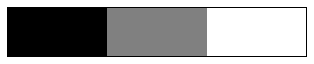

In [5]:
# read the image as a grayscale image (parameter 0)
img = cv2.imread('images/h-pattern2.png', 0).astype('float64') # change datatype to store arbitrary values
print("Original:")
plot_img_orig(img)

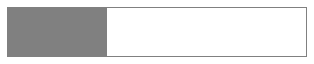

In [6]:
img = img+128
plot_img_orig(img)

50 300 50 300
50 300 50 300


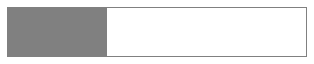

In [7]:
img_clip = clip(img)
plot_img_orig(img_clip)

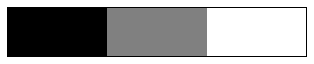

In [8]:
img_n = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX)
plot_img_orig(img_n)

#### <span style="color: RoyalBlue; font-weight: bold;">Task 8.2</span> Laplacian Filter

The Laplacian is the simplest isotropic derivative operator and can be implemented using one of the commonly used masks from the overview. As it is a derivative operator, it highlights gray-level discontinuities, and deemphasizes regions with slowly varying gray-levels. These properties can be exploited to enhance images: the background can be kept while integrating the sharpening effect of the Laplacian operation by subtracting (or adding) the original and the Laplacian images. Therefore:

$$
g(x,y) =
\begin{cases}
f(x,y)-\nabla^2 f(x,y) &\ \text{if the center coefficient is negative}\\
f(x,y)+\nabla^2 f(x,y) &\ \text{if the center coefficient is positive}\\
\end{cases}
$$

Implement / solve the following tasks:
1. Filter the image *fovea.jpg* using the first Laplacian mask and plot the clipped and normalized results.
2. Enhance the image using the given formula and plot the clipped and normalized results.
3. Repeat these tasks for the second Laplacian masks and compare the results.
4. Use one of the Laplacian masks with direct subtracting and show that the result is identical to using the given formula. 
5. What happens when the Laplacian filtered image is added instead of subtracted? Test it and explain the results.

Original:


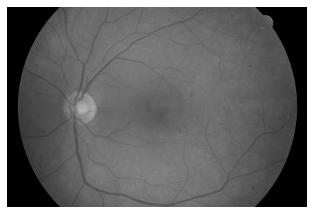

In [9]:
# write your code here

# read the image as a grayscale image (parameter 0)
img = cv2.imread('images/fovea.jpg', 0).astype('float64')
print("Original:")
plot_img_orig(img)



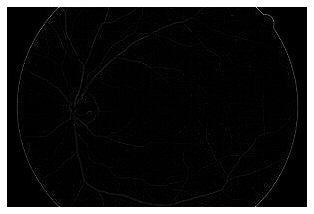

In [10]:

# === Laplacian mask (normal) ==================================================
laplace = np.array([[0,1,0],[1,-4,1],[0,1,0]])
res_laplace = cv2.filter2D(img, cv2.CV_64F, laplace)
plot_img_orig(res_laplace)

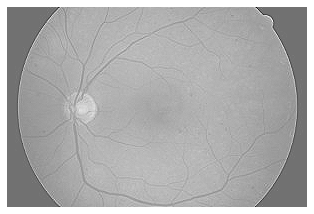

In [11]:
img_e = img-res_laplace
img_e_n = cv2.normalize(img_e, None, 0, 255, cv2.NORM_MINMAX)
plot_img_orig(img_e_n)

200 300 200 300
200 300 200 300


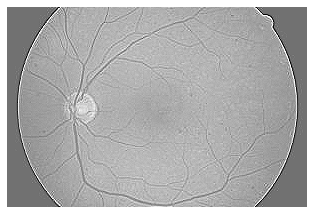

In [12]:
img_e_n_clip = clip(img_e_n) - res_laplace
plot_img_orig(img_e_n_clip)

In [13]:
# ...

# === Laplacian mask (with diagonal terms) =====================================

# ...

# === Laplacian mask with direct subtraction ===================================

# ...

#### <span style="color: RoyalBlue; font-weight: bold;">Task 8.3</span> Laplacian of Gaussian (LoG) Filter

As a second-order derivative, the Laplacian is unacceptably sensitive to noise, which is why an image is often Gaussian smoothed before applying the Laplacian. Since the convolution operation is associative, the LoG mask can be precalculated in advance by differentiating the corresponding Gaussian. The result is given as follows (the prefactor of the Gaussian has been set to $1$ here; the result is different for the prefactor $1/2\pi\sigma^2$):

$$
\mathrm{LoG}(r) =
\left(\dfrac{r^2-2\sigma^2}{\sigma^4}\right)
e^{-\dfrac{r^2}{2 \sigma^2}}
$$

In this equation, $r$ is the distance from the center of the mask, where $r^2 = x^2 + y^2$.

Implement / solve the following tasks:
1. Write a function to create a LoG filter mask with the size $n\times n$ mask ($n$ should be odd).
2. Reproduce the LoG mask from the overview as close as possible based on this function and print it.
3. Create a $301 \times 301$ Laplacian mask for $\sigma = 30$ and plot the mask coefficients as an image and as a function along the middle row (or column).
4. Filter the image *fovea.jpg* with the LoG mask from the overview. Plot and analyze the result.
5. Filter the image *moon-noise.png* with the Laplacian and mask and the LoG mask (use $\sigma = 2$ and $n = 21$ for the LoG). Plot and analyze the results with regard to edge detection.

In [2]:
# write your code here

# compute n x n LoG mask (n must be odd) with given sigma
def log_mask(sigma, n):
    # create empty mask
    log = np.zeros(shape=[n, n], dtype=np.float64) 
    rows, cols = log.shape
    c = int(n/2)

    for row in range(rows):
        for col in range(cols):
            r2 = (row-c)**2 + (col-c)**2
            log[row, col] = ((r2 - 2*sigma**2)/sigma**4)*np.exp(-r2/(2*sigma**2))
    return log

In [6]:
log = 2*log_mask(0.5, 5)
log = log.astype('int64')
print(log)

[[  0   0   0   0   0]
 [  0   0   2   0   0]
 [  0   2 -16   2   0]
 [  0   0   2   0   0]
 [  0   0   0   0   0]]


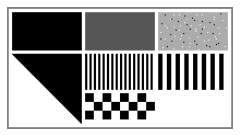

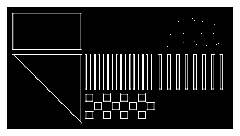

[[  0   0   0   0   0]
 [  0   0   2   0   0]
 [  0   2 -16   2   0]
 [  0   0   2   0   0]
 [  0   0   0   0   0]]


In [7]:
# write your code here
robert = log
# read the image as a grayscale image (parameter 0)
img = cv2.imread('images/image.png', 0).astype('float64')
plot_img_orig(img)
imgrob1 = cv2.filter2D(img, cv2.CV_64F, robert)
plot_img_orig(imgrob1)
# ...
print(robert)

#### <span style="color: RoyalBlue; font-weight: bold;">Task 8.4</span> Roberts (Cross) and Sobel Operator

First derivatives can be implemented using the magnitude of the gradient, which can be approximated using the Roberts and Sobel operator and the corresponding masks from the overview. The gradient is then typically approximated by the absolute values, for example, $|\nabla f| = |f_9 - f_5| + |f_8 - f_6|$ when using the two masks from the overview, taking the absolute values, and then summing up the results.

Implement / solve the following tasks:
1. Filter the image *p-building-small.png* with the masks of the Roberts Operator and plot the (normalized) results.
2. Repeat these tasks for the Sobel operator.
3. How do the results change when the image is rotated by 90 degrees?

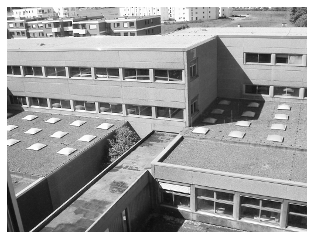

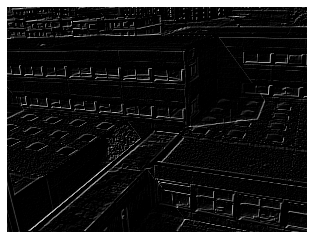

[[ 0  0  0]
 [ 0 -1  0]
 [ 0  0  1]]


In [30]:
# write your code here
robert = np.array([[0,0,0], [0,-1,0], [0,0,1]])
# read the image as a grayscale image (parameter 0)
img = cv2.imread('images/p-building-small.png', 0).astype('float64')
plot_img_orig(img)
imgrob1 = cv2.filter2D(img, cv2.CV_64F, robert)
plot_img_orig(imgrob1)
# ...
print(robert)


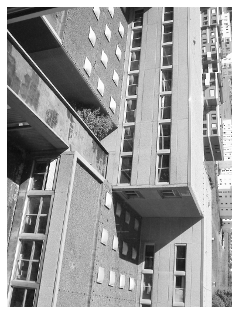

In [27]:

# rotate image (for your own tests)
img = cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE) # cv2.ROTATE_90_COUNTERCLOCKWISE to rotate back
plot_img_orig(img)

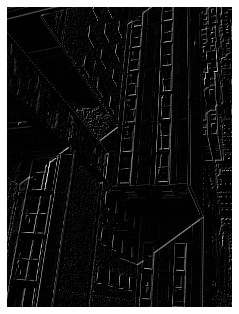

In [28]:
imgrob_r = cv2.filter2D(img, cv2.CV_64F, robert)
plot_img_orig(imgrob_r)

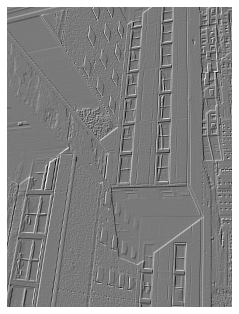

In [29]:
imgrob_r_n = cv2.normalize(imgrob_r, None, 0, 255, cv2.NORM_MINMAX)
plot_img_orig(imgrob_r_n)